# Sokoban — Comparación de Algoritmos de Búsqueda

**TP1 — Sistemas de Inteligencia Artificial — Grupo 4**

Este notebook corre **BFS, DFS, IDDFS, A\* y Greedy** (con distintas heurísticas y
modos de poda de *deadlocks*) sobre los **7 niveles** de Sokoban del proyecto, y
analiza los resultados: tiempo de cómputo, nodos expandidos, nodos en frontera,
costo de la solución y tasa de éxito.

Todo el código de búsqueda vive en `algorithms.py`, `state.py`, `heuristics.py`,
`engine.py`: este notebook no reimplementa nada, sólo lo ejecuta y lo mide.

In [1]:
import os
import sys

sys.path.append(os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from utils import load_level
from algorithms import ALGORITHMS, HEURISTICS
from engine import run_search

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['axes.axisbelow'] = True

LEVELS = [f"level-{i}" for i in range(1, 8)]
LEVEL_PATHS = {lvl: f"levels/{lvl}.txt" for lvl in LEVELS}

PALETTE = {
    'bfs': '#4c72b0', 'dfs': '#dd8452', 'iddfs': '#8c8c8c',
    'astar': '#55a868', 'greedy': '#c44e52',
}
HEUR_PALETTE = {
    'manhattan': '#4c72b0', 'hungarian': '#55a868',
    'push_distance_nearest': '#c44e52', 'push_distance': '#8172b2',
}

## 1. Los niveles

Cada nivel es un `.txt` con paredes (`#`), objetivos (`.`), cajas (`$`), jugador
(`@`), y combinaciones (`+` jugador sobre objetivo, `*` caja sobre objetivo).

In [2]:
level_info = []
for lvl in LEVELS:
    state, level = load_level(LEVEL_PATHS[lvl])
    all_pts = level.walls | level.goals | state.boxes | {state.player_pos}
    width = max(x for x, _ in all_pts) - min(x for x, _ in all_pts) + 1
    height = max(y for _, y in all_pts) - min(y for _, y in all_pts) + 1
    level_info.append({
        'level': lvl, 'width': width, 'height': height,
        'cells': width * height, 'walls': len(level.walls),
        'boxes': len(state.boxes), 'goals': len(level.goals),
    })

levels_df = pd.DataFrame(level_info).set_index('level')
levels_df

,width,height,cells,walls,boxes,goals
level,,,,,,
level-1,15,10,150,62,2,2
level-2,8,7,56,30,5,5
level-3,10,10,100,40,5,5
level-4,19,16,304,143,4,4
level-5,10,11,110,47,8,8
level-6,22,16,352,115,9,9
level-7,13,17,221,94,8,8


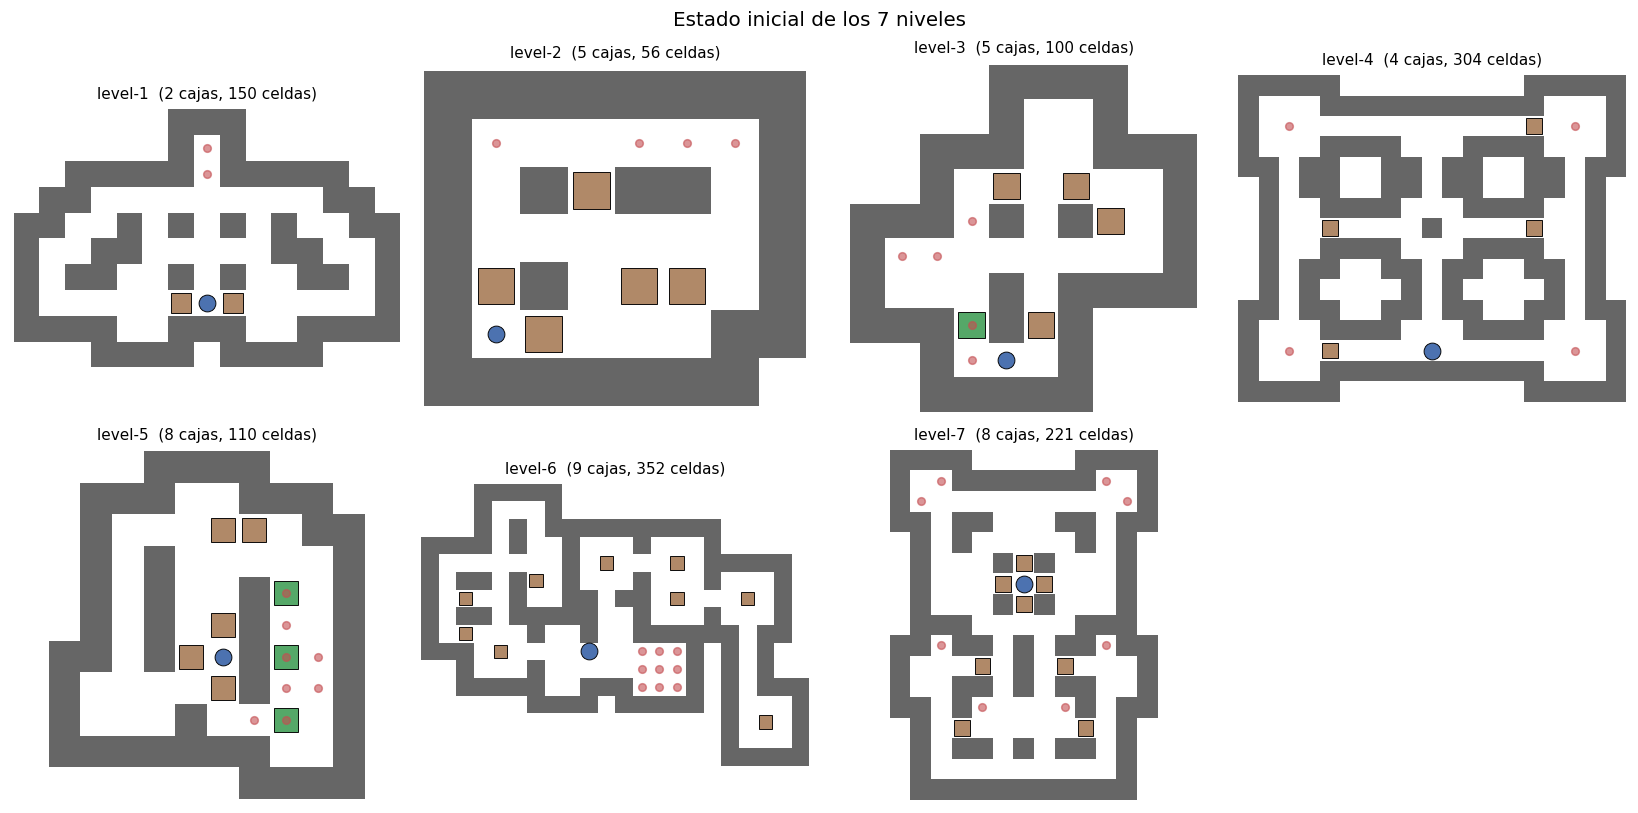

In [3]:
def draw_state(ax, state, level, title=None):
    all_points = level.walls | level.goals | state.boxes | {state.player_pos}
    min_x = min(p[0] for p in all_points); max_x = max(p[0] for p in all_points)
    min_y = min(p[1] for p in all_points); max_y = max(p[1] for p in all_points)

    ax.set_xlim(min_x - 0.6, max_x + 0.6)
    ax.set_ylim(max_y + 0.6, min_y - 0.6)
    ax.set_aspect('equal')
    ax.axis('off')

    for wx, wy in level.walls:
        ax.add_patch(plt.Rectangle((wx - 0.5, wy - 0.5), 1, 1, facecolor='#666666', edgecolor='none'))
    for gx, gy in level.goals:
        ax.plot(gx, gy, marker='o', markersize=5, color='#c44e52', alpha=0.6)
    for bx, by in state.boxes:
        color = '#55a868' if (bx, by) in level.goals else '#b08968'
        ax.add_patch(plt.Rectangle((bx - 0.38, by - 0.38), 0.76, 0.76, facecolor=color, edgecolor='black', linewidth=0.6))
    px, py = state.player_pos
    ax.plot(px, py, marker='o', markersize=11, color='#4c72b0', markeredgecolor='black', markeredgewidth=0.6)
    if title:
        ax.set_title(title, fontsize=10)


fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
for ax, lvl in zip(axes.flat, LEVELS):
    state, level = load_level(LEVEL_PATHS[lvl])
    n_boxes = levels_df.loc[lvl, 'boxes']
    draw_state(ax, state, level, title=f"{lvl}  ({n_boxes} cajas, {levels_df.loc[lvl, 'cells']} celdas)")
axes.flat[-1].axis('off')
fig.suptitle("Estado inicial de los 7 niveles", fontsize=13)
plt.tight_layout()
plt.show()

## 2. Metodología del benchmark

Para cada nivel se corrieron estas configuraciones:

- **No informadas** (sin heurística): `BFS`, `DFS`, `IDDFS`.
- **Informadas**: `A*` y `Greedy`, cada uno con 4 heurísticas:
  - `manhattan`: suma de distancias Manhattan caja→objetivo más cercano (no admite en general, ignora paredes).
  - `hungarian`: asignación óptima 1-a-1 caja↔objetivo por distancia Manhattan (algoritmo húngaro).
  - `push_distance_nearest`: distancia de *empuje* (respeta paredes) de cada caja a su objetivo más cercano.
  - `push_distance`: asignación óptima 1-a-1 caja↔objetivo por distancia de empuje (la más informada y costosa de calcular).
- **Poda de deadlocks**: todo lo anterior con `pruning_mode="dead_squares"` (precomputa casillas desde las que ningún objetivo es alcanzable), más una comparación extra de `BFS` y `A*+hungarian` con `pruning_mode="local"` (poda local más barata pero más débil).

Son **91 configuraciones**. Cada una corrió en **un proceso aislado** con un
timeout (30 s para las no informadas, 45 s para A\*/Greedy) para que una
búsqueda que explota en tiempo/memoria no cuelgue ni contamine las demás
corridas; los procesos corrieron en paralelo (`experiments/benchmark.py`).

Los resultados quedaron cacheados en `results/benchmark_results.csv`. Esta
celda los carga; para regenerarlos correr:

```bash
python experiments/benchmark.py
```

In [4]:
results_path = os.path.join('results', 'benchmark_results.csv')
raw = pd.read_csv(results_path)

df = raw.copy()
df['success'] = df['success'].astype('boolean')
df['timed_out'] = df['timed_out'].astype('boolean')
df['heuristic'] = df['heuristic'].fillna('')
df['config'] = np.where(
    df['heuristic'] != '',
    df['algorithm'] + '+' + df['heuristic'],
    df['algorithm'],
)
df['status'] = np.select(
    [df['timed_out'] == True, df['success'] == True],
    ['timeout', 'ok'],
    default='error',
)
df['level_n'] = df['level'].str.extract(r'(\d+)').astype(int)
df = df.sort_values(['level_n', 'algorithm', 'heuristic']).reset_index(drop=True)

main_grid = df[df['pruning_mode'] == 'dead_squares'].copy()
pruning_cmp = df[df['algorithm'].isin(['bfs', 'astar']) & (df['heuristic'].isin(['', 'hungarian']))].copy()

print(f"{len(df)} corridas cargadas -> {df['status'].value_counts().to_dict()}")
df.head()

91 corridas cargadas -> {'ok': 52, 'timeout': 39}


,level,n_boxes,n_goals,algorithm,heuristic,pruning_mode,success,timed_out,cost,expanded_nodes,frontier_nodes,time_sec,wall_time_sec,timeout_budget_sec,config,status,level_n
0,level-1,2.0,2.0,astar,hungarian,dead_squares,True,False,78.0,15563.0,42.0,0.088237,0.1568,45,astar+hungarian,ok,1
1,level-1,2.0,2.0,astar,hungarian,local,True,False,78.0,15563.0,42.0,0.088155,0.1536,45,astar+hungarian,ok,1
2,level-1,2.0,2.0,astar,manhattan,dead_squares,True,False,78.0,15588.0,35.0,0.088385,0.1550,45,astar+manhattan,ok,1
3,level-1,2.0,2.0,astar,push_distance,dead_squares,True,False,78.0,15563.0,42.0,0.089186,0.1511,45,astar+push_distance,ok,1
4,level-1,2.0,2.0,astar,push_distance_nearest,dead_squares,True,False,78.0,15588.0,35.0,0.087357,0.1488,45,astar+push_distance_nearest,ok,1


## 3. ¿Quién termina? Tasa de éxito por nivel

`ok` = encontró solución dentro del timeout. `timeout` = seguía corriendo
cuando se lo mató. `error` = excepción (no debería aparecer).

C:\Users\nacho\AppData\Local\Temp\ipykernel_14880\621708184.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grid = status_matrix.replace(code_map).astype(float)


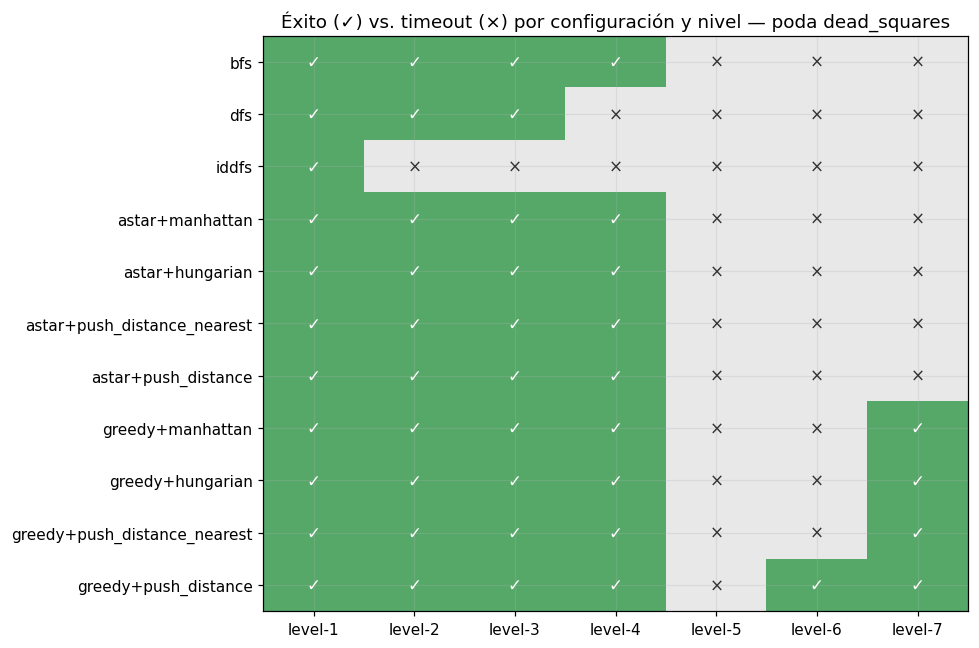

In [5]:
status_matrix = main_grid.pivot_table(index='config', columns='level', values='status', aggfunc='first')
status_matrix = status_matrix.reindex(columns=LEVELS)

order = (['bfs', 'dfs', 'iddfs']
         + [f'astar+{h}' for h in ('manhattan', 'hungarian', 'push_distance_nearest', 'push_distance')]
         + [f'greedy+{h}' for h in ('manhattan', 'hungarian', 'push_distance_nearest', 'push_distance')])
status_matrix = status_matrix.reindex(order)

code_map = {'ok': 1, 'timeout': 0, 'error': -1}
grid = status_matrix.replace(code_map).astype(float)

fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.matplotlib.colors.ListedColormap(['#c44e52', '#e8e8e8', '#55a868'])
im = ax.imshow(grid.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(grid.columns)))
ax.set_xticklabels(grid.columns, rotation=0)
ax.set_yticks(range(len(grid.index)))
ax.set_yticklabels(grid.index)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        label = status_matrix.values[i, j]
        symbol = {'ok': '✓', 'timeout': '×', 'error': '!'}.get(label, '?')
        ax.text(j, i, symbol, ha='center', va='center', fontsize=11,
                color='white' if label == 'ok' else '#333333')
ax.set_title("Éxito (✓) vs. timeout (×) por configuración y nivel — poda dead_squares")
plt.tight_layout()
plt.show()

In [6]:
solve_rate = (main_grid.assign(alg_label=np.where(main_grid['heuristic'] != '',
                                                     main_grid['algorithm'] + ' (' + main_grid['heuristic'] + ')',
                                                     main_grid['algorithm']))
              .groupby('algorithm')['status']
              .value_counts(normalize=True)
              .unstack(fill_value=0)
              .reindex(['bfs', 'dfs', 'iddfs', 'astar', 'greedy']))
(solve_rate * 100).round(1)

status,ok,timeout
algorithm,,
bfs,57.1,42.9
dfs,42.9,57.1
iddfs,14.3,85.7
astar,57.1,42.9
greedy,75.0,25.0


## 4. No informada vs. informada: nodos expandidos y tiempo

Comparamos `BFS`, `DFS`, `IDDFS` contra `A*` y `Greedy` (ambos con la
heurística `hungarian`) en cada nivel. Escala logarítmica: las diferencias son
de varios órdenes de magnitud.

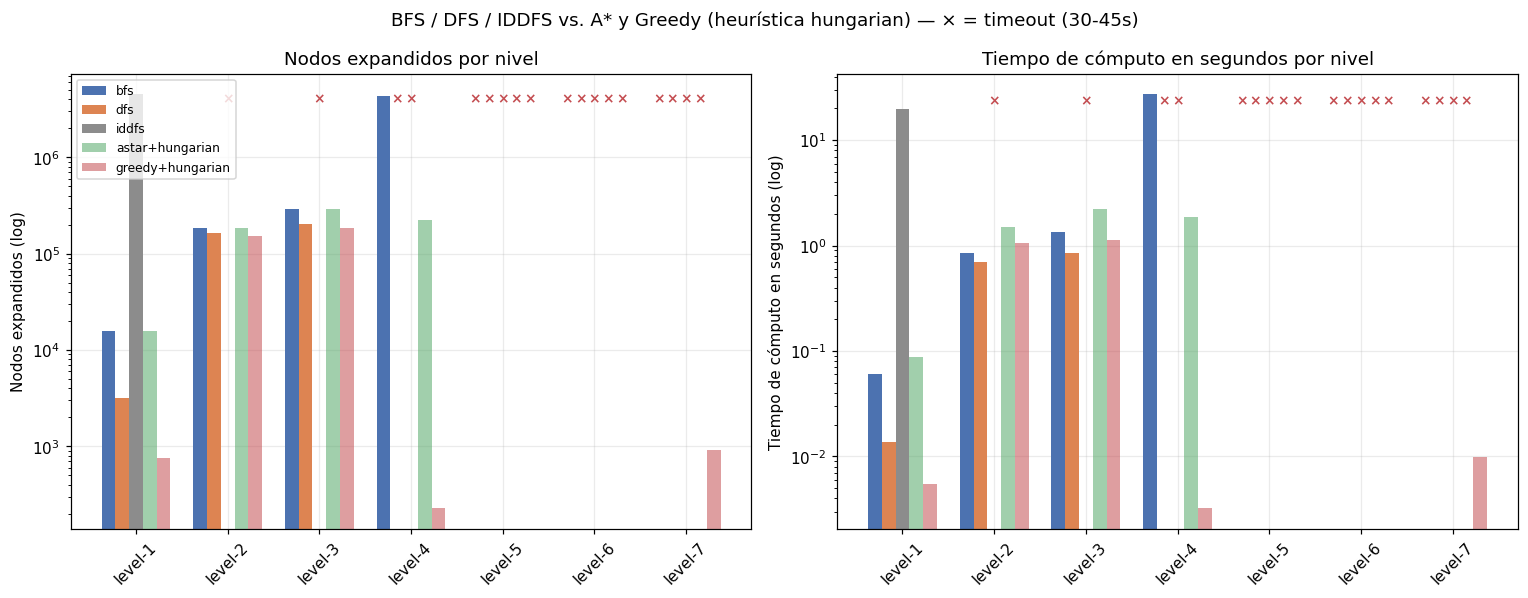

In [7]:
headline = ['bfs', 'dfs', 'iddfs', 'astar+hungarian', 'greedy+hungarian']
plot_df = main_grid[main_grid['config'].isin(headline)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for metric, ax, ylabel in zip(
    ['expanded_nodes', 'time_sec'], axes,
    ['Nodos expandidos (log)', 'Tiempo de cómputo en segundos (log)'],
):
    pivot = plot_df.pivot_table(index='level', columns='config', values=metric)
    pivot = pivot.reindex(index=LEVELS, columns=headline)
    x = np.arange(len(LEVELS))
    width = 0.15
    for i, cfg in enumerate(headline):
        vals = pivot[cfg].values
        color = PALETTE[cfg.split('+')[0]]
        bars = ax.bar(x + (i - 2) * width, vals, width, label=cfg, color=color,
                       alpha=0.55 if 'astar' in cfg or 'greedy' in cfg else 1.0)
    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels(LEVELS, rotation=45)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel.split(' (')[0] + ' por nivel')

# mark timeouts with an 'x' above the axis for missing bars
for metric, ax in zip(['expanded_nodes', 'time_sec'], axes):
    pivot_status = plot_df.pivot_table(index='level', columns='config', values='status', aggfunc='first')
    pivot_status = pivot_status.reindex(index=LEVELS, columns=headline)
    ymax = ax.get_ylim()[1]
    x = np.arange(len(LEVELS))
    width = 0.15
    for i, cfg in enumerate(headline):
        for j, lvl in enumerate(LEVELS):
            if pivot_status.loc[lvl, cfg] == 'timeout':
                ax.text(x[j] + (i - 2) * width, ymax * 0.55, '×', ha='center', va='center',
                        fontsize=9, color='#c44e52', fontweight='bold')

axes[0].legend(loc='upper left', fontsize=8, ncol=1)
plt.suptitle("BFS / DFS / IDDFS vs. A* y Greedy (heurística hungarian) — × = timeout (30-45s)")
plt.tight_layout()
plt.show()

## 5. Duelo de heurísticas (A\* y Greedy)

¿Cuánto importa la heurística elegida? Comparamos las 4 heurísticas sólo en
los niveles donde **A\*** terminó con las 4.

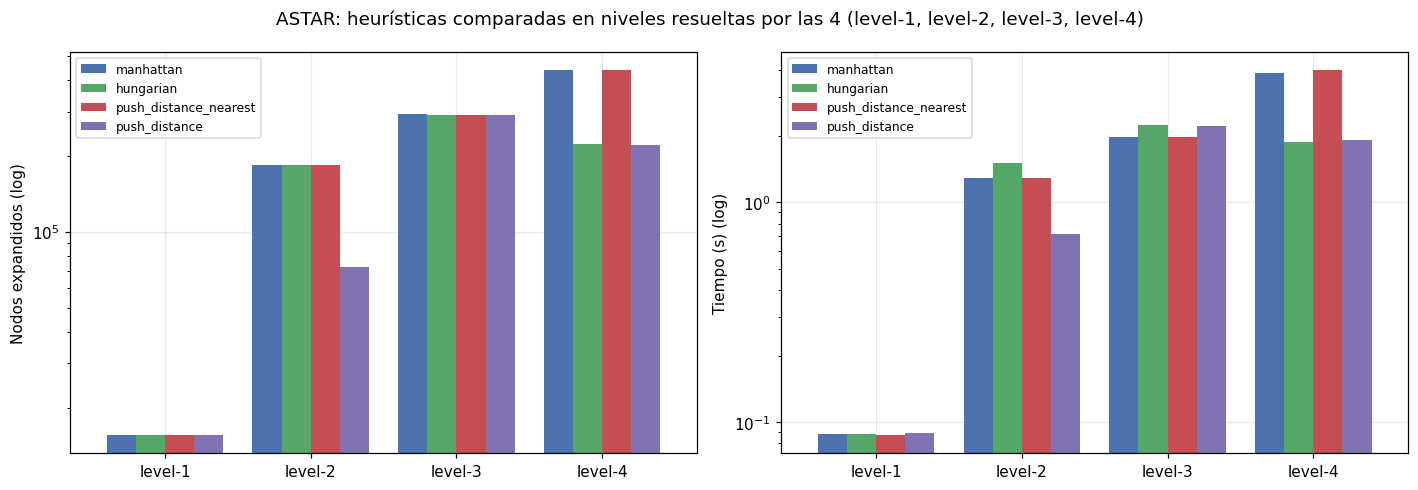

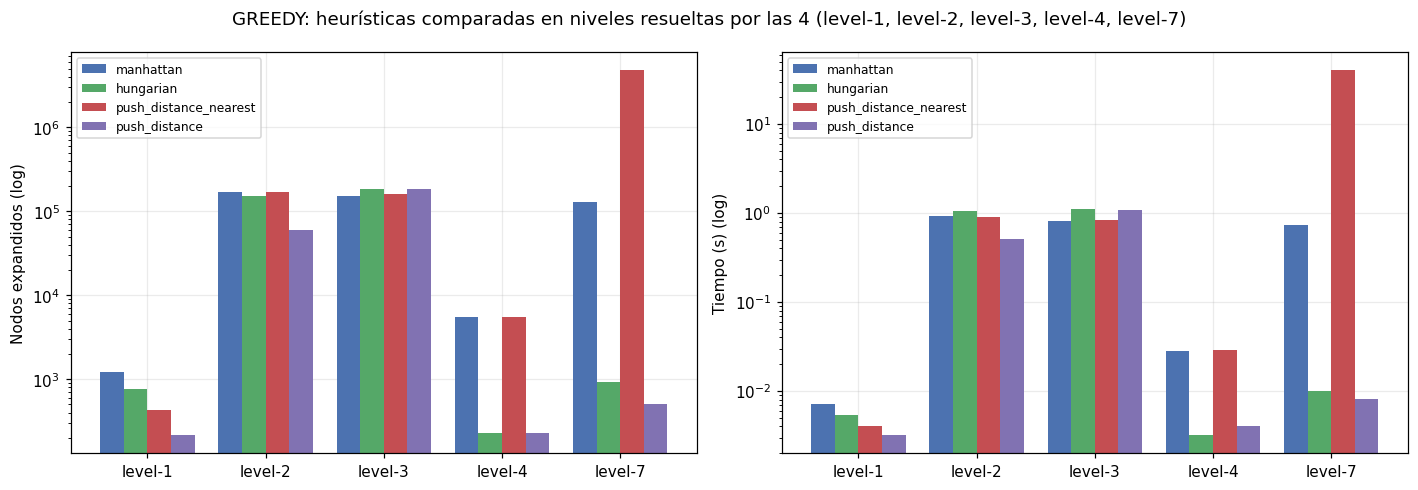

In [8]:
heuristics_order = ['manhattan', 'hungarian', 'push_distance_nearest', 'push_distance']

for algo in ['astar', 'greedy']:
    sub = main_grid[main_grid['algorithm'] == algo]
    solved_all = (sub.pivot_table(index='level', columns='heuristic', values='status', aggfunc='first')
                  .reindex(columns=heuristics_order))
    solved_levels = solved_all[(solved_all == 'ok').all(axis=1)].index.tolist()
    solved_levels = [lvl for lvl in LEVELS if lvl in solved_levels]

    if not solved_levels:
        print(f"{algo}: ninguna heurística resolvió el mismo conjunto de niveles a tiempo")
        continue

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for metric, ax, ylabel in zip(['expanded_nodes', 'time_sec'], axes,
                                   ['Nodos expandidos', 'Tiempo (s)']):
        pivot = sub[sub['level'].isin(solved_levels)].pivot_table(index='level', columns='heuristic', values=metric)
        pivot = pivot.reindex(index=solved_levels, columns=heuristics_order)
        pivot.plot(kind='bar', ax=ax, color=[HEUR_PALETTE[h] for h in heuristics_order], width=0.8)
        ax.set_yscale('log')
        ax.set_ylabel(ylabel + ' (log)')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=0)
        ax.legend(fontsize=8)
    plt.suptitle(f"{algo.upper()}: heurísticas comparadas en niveles resueltas por las 4 ({', '.join(solved_levels)})")
    plt.tight_layout()
    plt.show()

## 6. Optimalidad: ¿todos dan la misma solución?

`BFS` y `A*` (con una heurística admisible) garantizan el **costo óptimo**.
`Greedy` y `DFS` no lo garantizan. Comparamos el costo (en movimientos) de
cada algoritmo contra el óptimo de `BFS`, en los niveles donde ambos
terminaron.

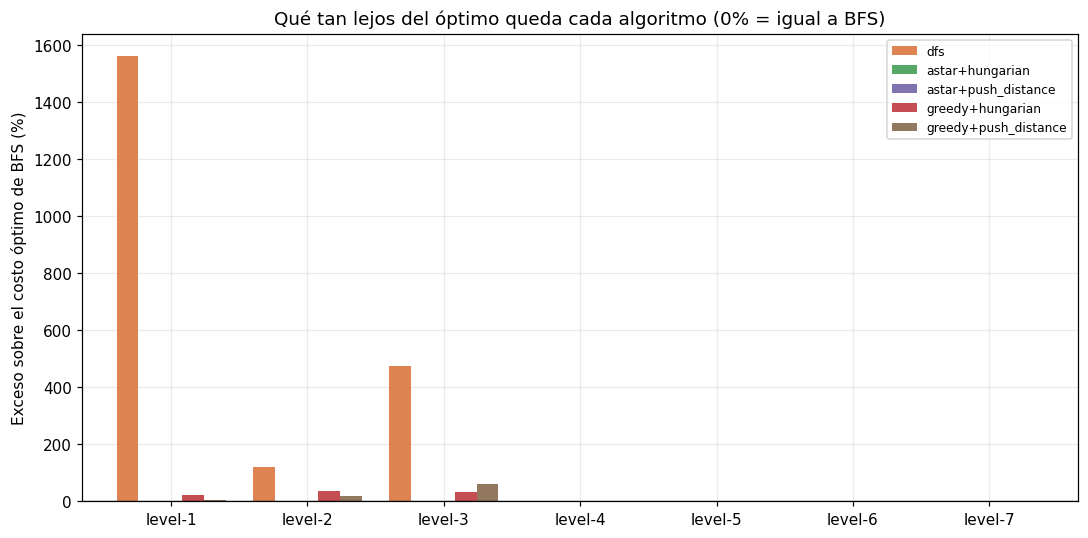

A* siempre debería dar 0% (heurísticas admisibles) si terminó dentro del timeout:


config,astar+hungarian,astar+manhattan,astar+push_distance,astar+push_distance_nearest
level,,,,
level-1,0.0,0.0,0.0,0.0
level-2,0.0,0.0,0.0,0.0
level-3,0.0,0.0,0.0,0.0
level-4,0.0,0.0,0.0,0.0


In [9]:
bfs_cost = main_grid[(main_grid['algorithm'] == 'bfs') & (main_grid['status'] == 'ok')].set_index('level')['cost']

rows = []
for cfg in main_grid['config'].unique():
    sub = main_grid[(main_grid['config'] == cfg) & (main_grid['status'] == 'ok')].set_index('level')
    for lvl in sub.index:
        if lvl in bfs_cost.index:
            rows.append({'level': lvl, 'config': cfg, 'cost': sub.loc[lvl, 'cost'],
                         'optimal': bfs_cost[lvl], 'excess_pct': 100 * (sub.loc[lvl, 'cost'] / bfs_cost[lvl] - 1)})
cost_df = pd.DataFrame(rows)

focus = ['dfs', 'astar+hungarian', 'astar+push_distance', 'greedy+hungarian', 'greedy+push_distance']
pivot = cost_df[cost_df['config'].isin(focus)].pivot_table(index='level', columns='config', values='excess_pct')
pivot = pivot.reindex(index=LEVELS, columns=focus)

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', ax=ax, color=['#dd8452', '#55a868', '#8172b2', '#c44e52', '#937860'], width=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Exceso sobre el costo óptimo de BFS (%)')
ax.set_xlabel('')
ax.set_title('Qué tan lejos del óptimo queda cada algoritmo (0% = igual a BFS)')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("A* siempre debería dar 0% (heurísticas admisibles) si terminó dentro del timeout:")
cost_df[cost_df['config'].str.startswith('astar')].pivot_table(index='level', columns='config', values='excess_pct')

## 7. Poda de deadlocks: `dead_squares` vs. `local`

`dead_squares` precomputa, para todo el tablero, qué casillas nunca pueden
llevar a una solución (BFS hacia atrás desde los objetivos). `local` sólo
mira si la caja quedó encajonada entre paredes en las 4 direcciones
inmediatas — más barato de evaluar, pero detecta muchos menos deadlocks.
Comparamos ambos modos con `BFS` y `A*+hungarian`.

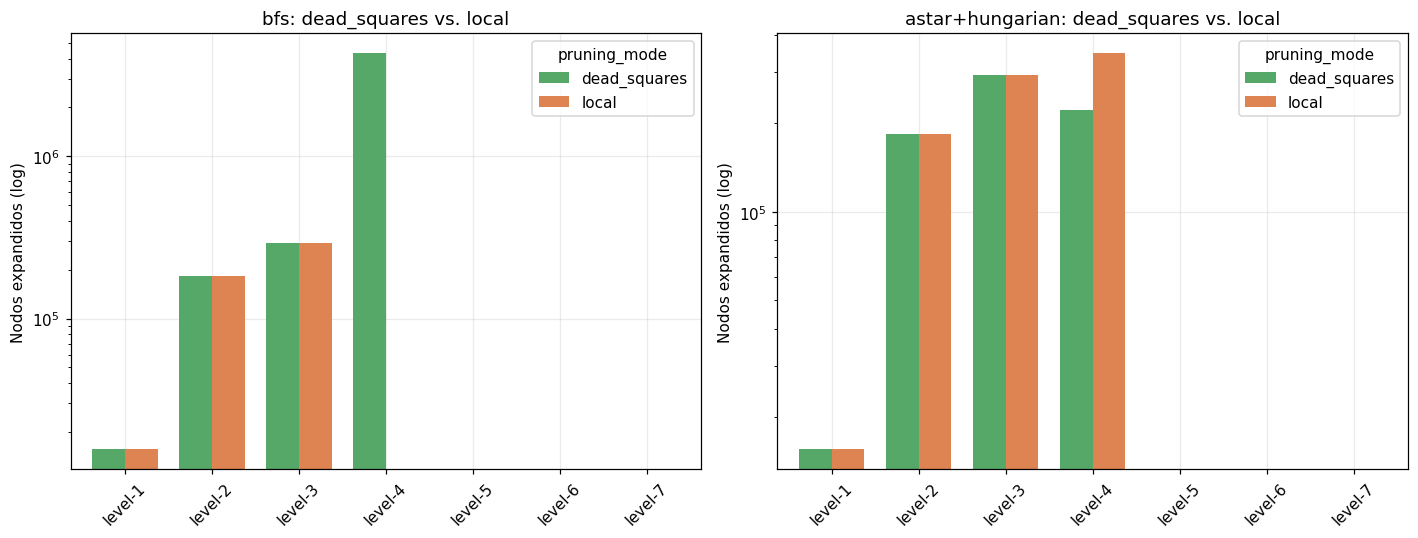

In [10]:
pc = pruning_cmp.copy()
pc['config'] = pc['algorithm'] + np.where(pc['heuristic'] != '', '+' + pc['heuristic'], '')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for algo, ax in zip(['bfs', 'astar+hungarian'], axes):
    sub = pc[pc['config'] == algo]
    pivot = sub.pivot_table(index='level', columns='pruning_mode', values='expanded_nodes')
    pivot = pivot.reindex(index=LEVELS, columns=['dead_squares', 'local'])
    pivot.plot(kind='bar', ax=ax, color=['#55a868', '#dd8452'], width=0.75)
    ax.set_yscale('log')
    ax.set_ylabel('Nodos expandidos (log)')
    ax.set_xlabel('')
    ax.set_title(f'{algo}: dead_squares vs. local')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 8. Tamaño del problema vs. dificultad

¿Más cajas siempre implica más nodos expandidos? Cada punto es una corrida
exitosa; el eje X es el número de cajas del nivel.

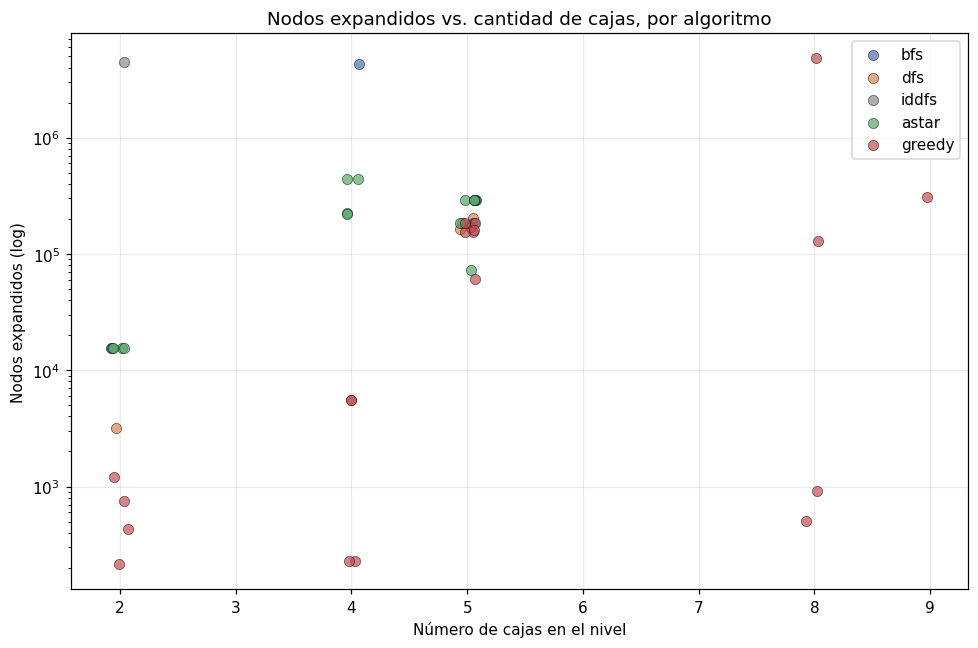

In [11]:
solved = main_grid[main_grid['status'] == 'ok'].merge(levels_df[['boxes']], left_on='level', right_index=True)

fig, ax = plt.subplots(figsize=(9, 6))
for algo, color in PALETTE.items():
    sub = solved[solved['algorithm'] == algo]
    if sub.empty:
        continue
    jitter = (np.random.RandomState(hash(algo) % 2**32).rand(len(sub)) - 0.5) * 0.15
    ax.scatter(sub['boxes'] + jitter, sub['expanded_nodes'], label=algo, color=color, alpha=0.7, s=45,
               edgecolor='black', linewidth=0.4)
ax.set_yscale('log')
ax.set_xlabel('Número de cajas en el nivel')
ax.set_ylabel('Nodos expandidos (log)')
ax.set_title('Nodos expandidos vs. cantidad de cajas, por algoritmo')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Mejor configuración global

Para cada nivel resuelto, ¿qué configuración informada expandió menos nodos?

In [12]:
informed = main_grid[main_grid['algorithm'].isin(['astar', 'greedy']) & (main_grid['status'] == 'ok')]
best_per_level = informed.loc[informed.groupby('level')['expanded_nodes'].idxmin()]
best_per_level = best_per_level.set_index('level').reindex(LEVELS)[['config', 'expanded_nodes', 'time_sec', 'cost']]
best_per_level

,config,expanded_nodes,time_sec,cost
level,,,,
level-1,greedy+push_distance,216.0,0.003201,82.0
level-2,greedy+push_distance,60498.0,0.517412,167.0
level-3,greedy+manhattan,153733.0,0.819437,250.0
level-4,greedy+hungarian,227.0,0.003217,70.0
level-5,NaN,NaN,NaN,NaN
level-6,greedy+push_distance,307628.0,1.941368,457.0
level-7,greedy+push_distance,502.0,0.008137,153.0


In [13]:
astar_solved = main_grid[(main_grid['algorithm'] == 'astar') & (main_grid['status'] == 'ok')]
common_levels = (astar_solved.groupby('heuristic')['level'].apply(set)
                  .pipe(lambda s: set.intersection(*s) if len(s) else set()))

summary = (astar_solved[astar_solved['level'].isin(common_levels)]
           .groupby('heuristic')[['expanded_nodes', 'time_sec']]
           .sum()
           .reindex(heuristics_order))
summary['expanded_nodes_relative'] = summary['expanded_nodes'] / summary['expanded_nodes'].min()
summary.round(3)

,expanded_nodes,time_sec,expanded_nodes_relative
heuristic,,,
manhattan,929957.0,7.238,1.547
hungarian,713546.0,5.721,1.187
push_distance_nearest,929712.0,7.350,1.547
push_distance,600964.0,4.952,1.000


## 10. Conclusiones

- **Las búsquedas no informadas no escalan.** `BFS`/`DFS`/`IDDFS` resuelven
  los niveles 1-3 (pocas cajas, tablero chico) en menos de 2 segundos, pero
  en el nivel 4 ya cuesta muchísimo más: `BFS` expande 4.3M nodos y tarda
  ~19x más que `A*+hungarian` (222 mil nodos) para llegar al mismo costo
  óptimo, y tanto `DFS` como `IDDFS` ya no terminan dentro del timeout.
  `IDDFS` es el peor de todos: reinicia la búsqueda desde profundidad 0 en
  cada iteración, así que paga muchas veces el costo de explorar los
  niveles superficiales del árbol (ya en el nivel 2 supera los 30 s).
- **La heurística importa, pero depende del algoritmo.** Para `A*`, la
  distancia de empuje óptima (`push_distance`) nunca expande más nodos que
  las demás — en el nivel 2 los reduce a menos de la mitad (72 mil vs. 183
  mil de `manhattan`/`hungarian`). Para `Greedy` el resultado es más
  delicado: `push_distance` (asignación óptima) es la más sólida, mientras
  que `push_distance_nearest` (cada caja va "a lo egoísta" hacia su
  objetivo más cercano, sin coordinarse con las demás) puede ser
  catastrófica — en el nivel 7 expande 4.8M de nodos (40 s) contra apenas
  502 de `push_distance`. Una heurística más informada por celda no
  garantiza mejor comportamiento si ignora los conflictos entre cajas.
- **`A*` es óptimo, `Greedy` es rápido pero no.** En todos los niveles donde
  `A*` terminó, su costo coincide exactamente con el de `BFS` (heurísticas
  admisibles, 0% de exceso). `Greedy` encuentra soluciones con muchos menos
  nodos expandidos y en una fracción del tiempo, a costa de quedar entre
  ~10% y ~60% por encima del óptimo — lejos, eso sí, del desastre de `DFS`
  (hasta +1560% en el nivel 1).
- **La poda de deadlocks no siempre cambia nada — hasta que cambia todo.**
  En los niveles 1-3, `dead_squares` y `local` expanden exactamente los
  mismos nodos: no hay rincones muertos que uno detecte y el otro no. En
  el nivel 4 sí importa: `A*+hungarian` expande 1.56x menos nodos con
  `dead_squares` (222 mil vs. 347 mil), y `BFS` sólo logra terminar dentro
  del timeout con `dead_squares` — con `local` no resuelve el nivel 4 en
  30 s. La poda global paga su costo de precómputo únicamente en los
  tableros donde existen esas trampas.
- **El tamaño del problema (cajas) predice la dificultad, pero no
  linealmente.** Los niveles 5 y 6 fueron los más duros del set: ni
  siquiera `A*` con la mejor heurística los resolvió dentro de 45 s en
  ninguna configuración. `Greedy`, al sacrificar la garantía de
  optimalidad, sí logró colarse por el nivel 7 completo y parcialmente
  por el nivel 6 (sólo con `push_distance`) — lo que sugiere que el factor
  de ramificación efectivo y la geometría del tablero importan tanto como
  la cantidad de cajas.